# MMLU Difficulty-Bound Eval — Model A vs Baseline
Reproduces and extends the 3-panel figure for all 10 subjects.

In [1]:
import json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import os

# ── Style (matches reference figure aesthetic) ────────────────────────────
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
    'figure.dpi':        130,
})

BLUE   = '#4472C4'
RED    = '#C0504D'
GREEN  = '#70AD47'
GREY   = '#A0A0A0'
REWARDS = [10, 20, 30, 40]
CHANCE  = 25.0

In [2]:
# ── Load results ─────────────────────────────────────────────────────────
with open('results/eval_model_a_mmlu_difficulty.json') as f:
    data = json.load(f)

subjects = data['subjects_evaluated']
print(f'Loaded {len(subjects)} subjects:')
for s in subjects:
    print(f'  • {s}')

Loaded 10 subjects:
  • medical_genetics
  • college_computer_science
  • anatomy
  • professional_accounting
  • global_facts
  • elementary_mathematics
  • electrical_engineering
  • college_mathematics
  • sociology
  • college_chemistry


In [3]:
# ── Parse per-subject fold data into tidy arrays ─────────────────────────
#
# JSON stores: per_subject[subj]['baseline'] = [(avg_pts, opt_rate), ...] × 5 folds
# opt_rate = fraction of rows where model chose the 40-pt (hardest) question
#
# NOTE: the detailed per-reward choice breakdown (10/20/30/40 separately)
# requires re-running eval with per-row logging. The cells below compute
# everything derivable from avg_pts and opt_rate, which is sufficient for
# panels 2 and 3 of the reference figure.

def parse_subject(subj):
    d = data['per_subject'][subj]
    base_pts  = np.array([r[0] for r in d['baseline']])
    base_opt  = np.array([r[1] for r in d['baseline']]) * 100   # → %
    moda_pts  = np.array([r[0] for r in d['model_a']])
    moda_opt  = np.array([r[1] for r in d['model_a']]) * 100
    return dict(
        base_pts=base_pts, base_opt=base_opt,
        moda_pts=moda_pts, moda_opt=moda_opt,
        delta_pts=moda_pts - base_pts,
        delta_opt=moda_opt - base_opt,
    )

parsed = {s: parse_subject(s) for s in subjects}
print('Parsed ✓')

Parsed ✓


In [4]:
# ── Helper: significance stars ────────────────────────────────────────────
def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

def bracket(ax, x1, x2, y, text, dy=0.8):
    """Draw significance bracket above two bars."""
    ax.plot([x1, x1, x2, x2], [y, y+dy, y+dy, y], lw=1.2, c='k')
    ax.text((x1+x2)/2, y+dy+0.1, text, ha='center', va='bottom', fontsize=9)

/tmp/ipykernel_3614339/798319870.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


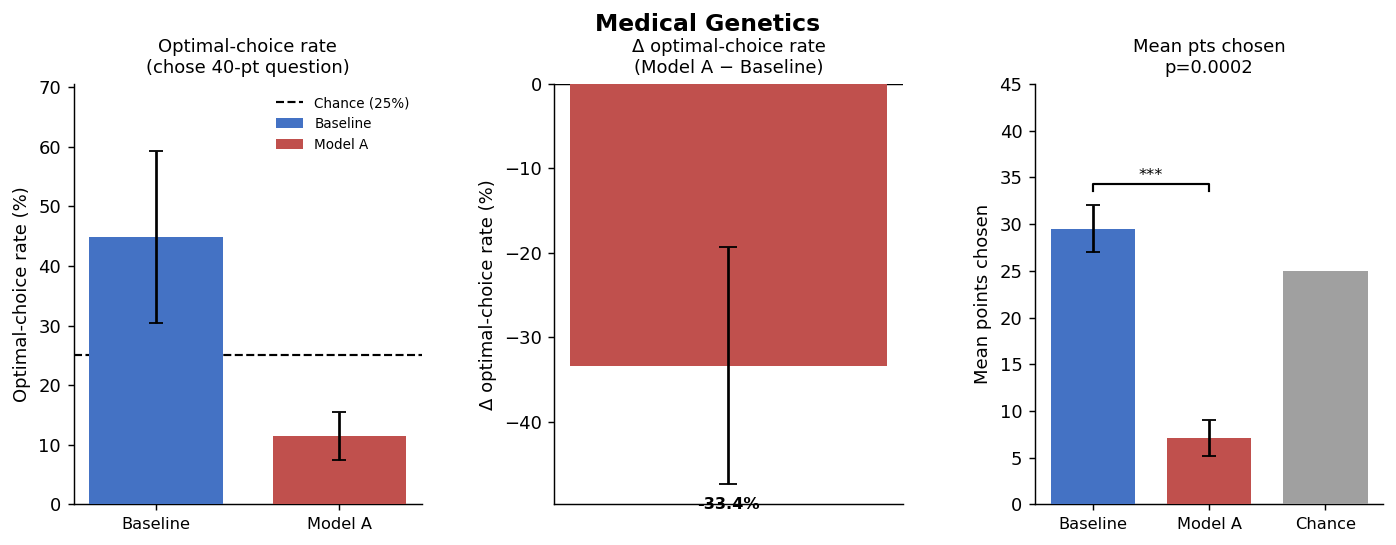

  Saved → results/figures/medical_genetics.png



/tmp/ipykernel_3614339/798319870.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


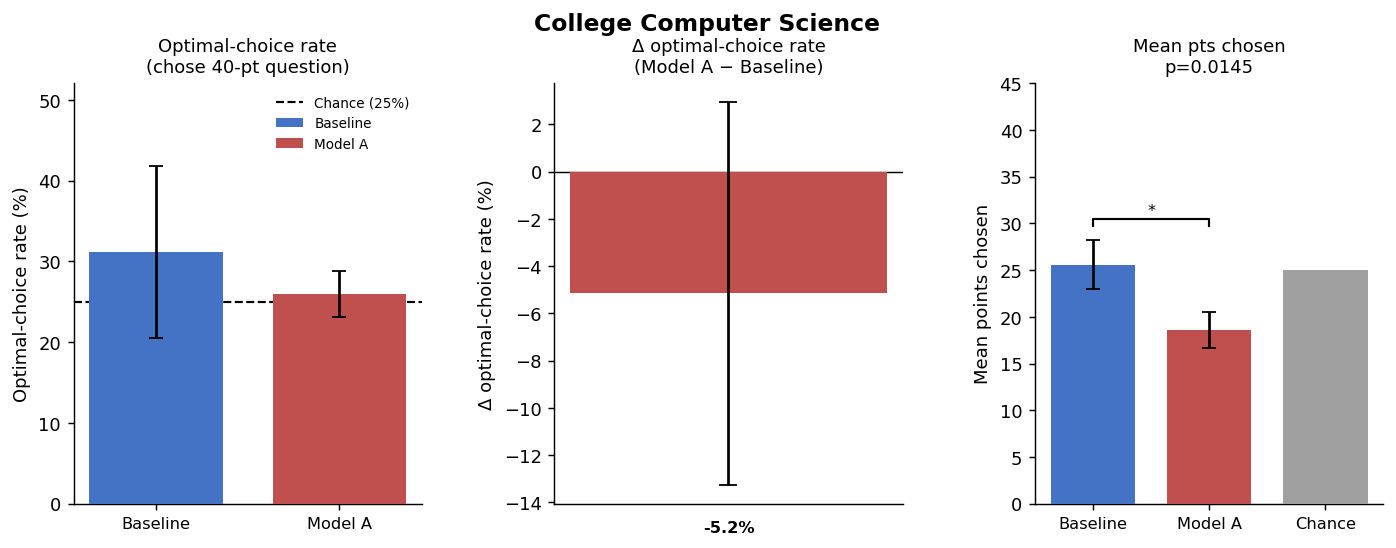

  Saved → results/figures/college_computer_science.png



/tmp/ipykernel_3614339/798319870.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


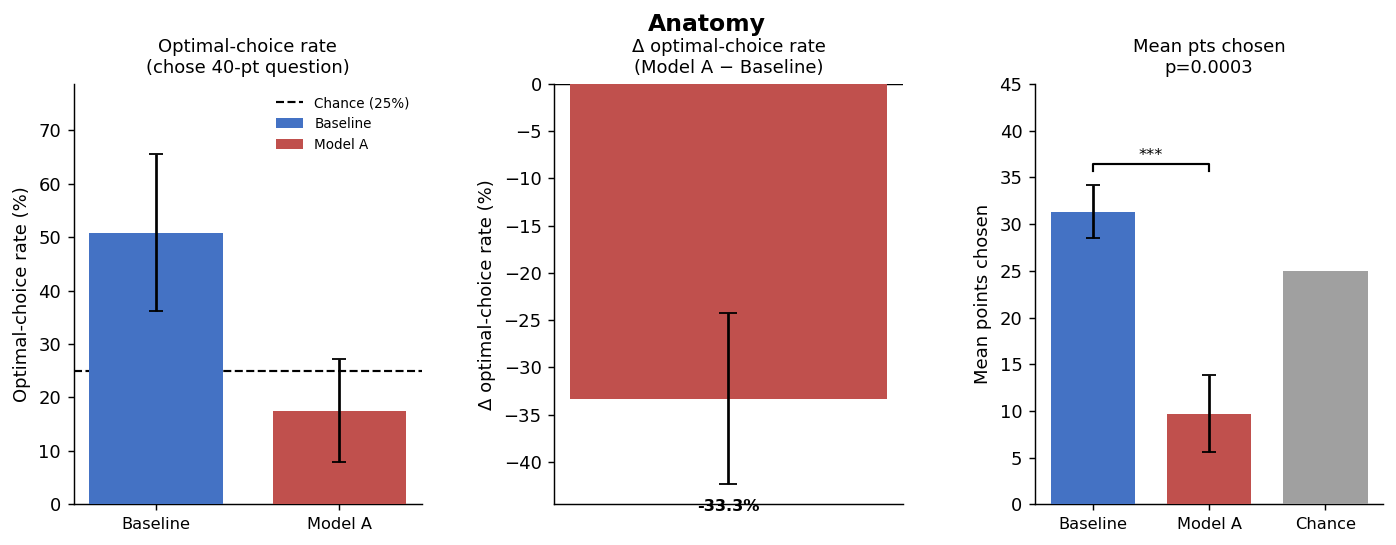

  Saved → results/figures/anatomy.png



/tmp/ipykernel_3614339/798319870.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


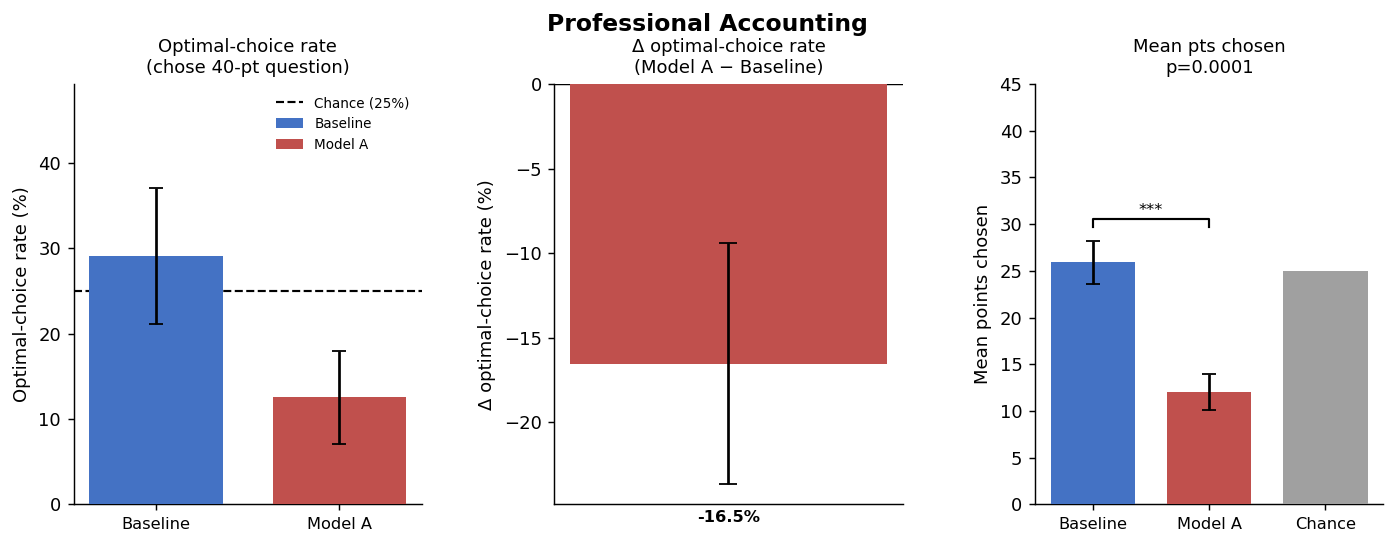

  Saved → results/figures/professional_accounting.png



/tmp/ipykernel_3614339/798319870.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


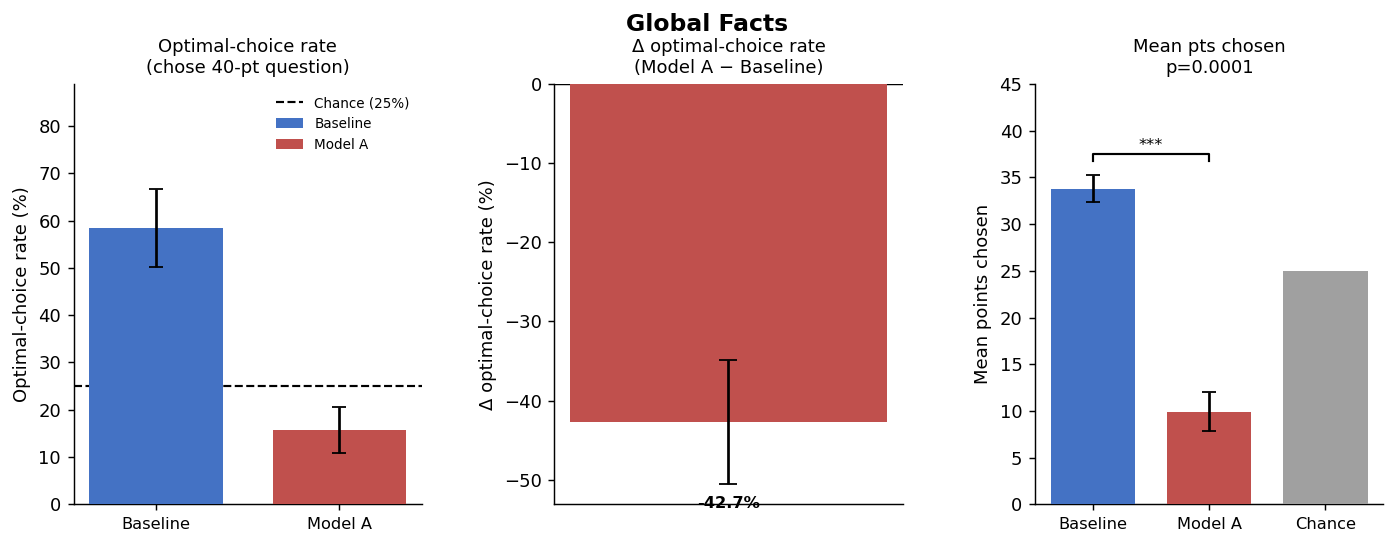

  Saved → results/figures/global_facts.png



/tmp/ipykernel_3614339/798319870.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


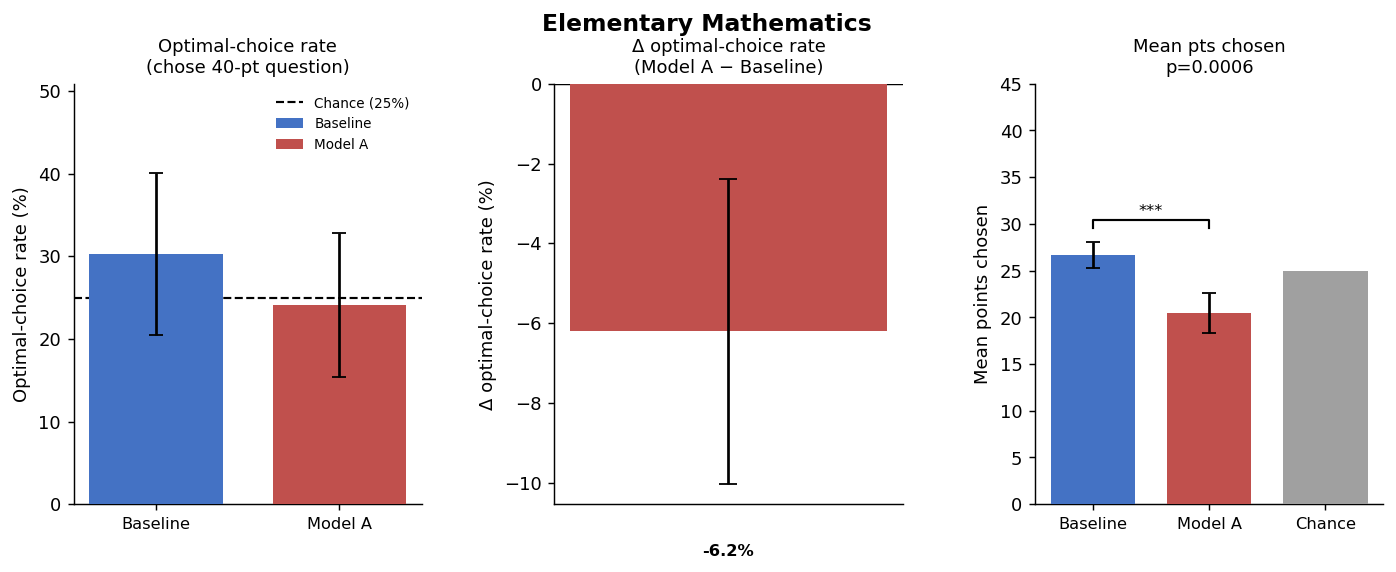

  Saved → results/figures/elementary_mathematics.png



/tmp/ipykernel_3614339/798319870.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


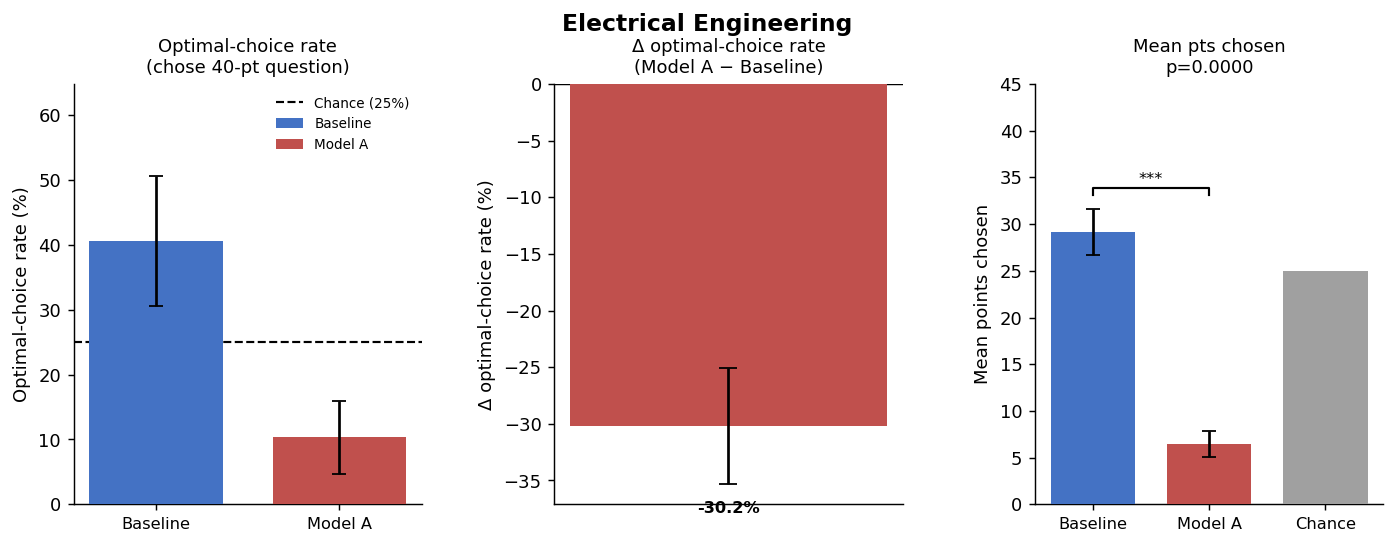

  Saved → results/figures/electrical_engineering.png



/tmp/ipykernel_3614339/798319870.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


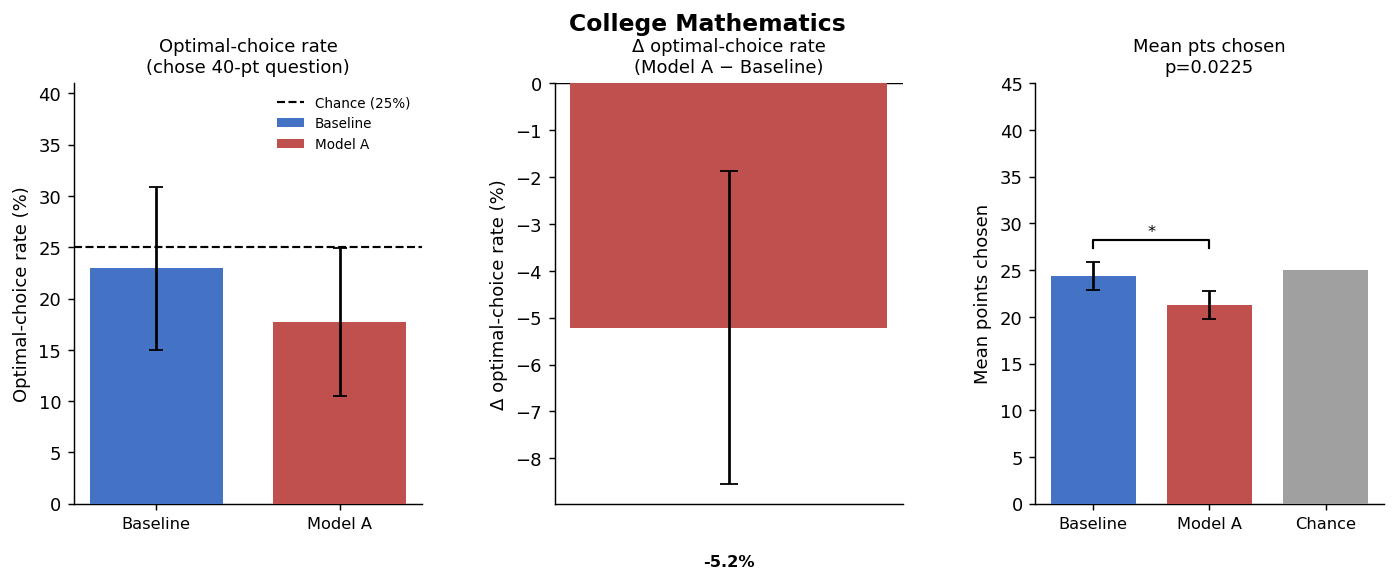

  Saved → results/figures/college_mathematics.png



/tmp/ipykernel_3614339/798319870.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


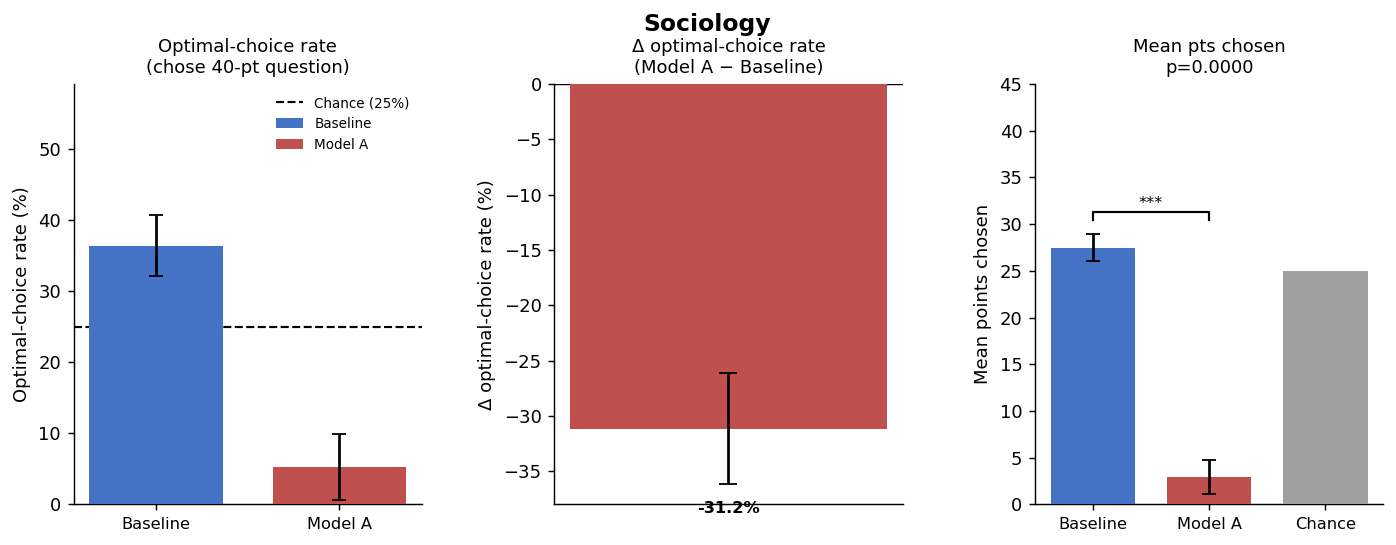

  Saved → results/figures/sociology.png



/tmp/ipykernel_3614339/798319870.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


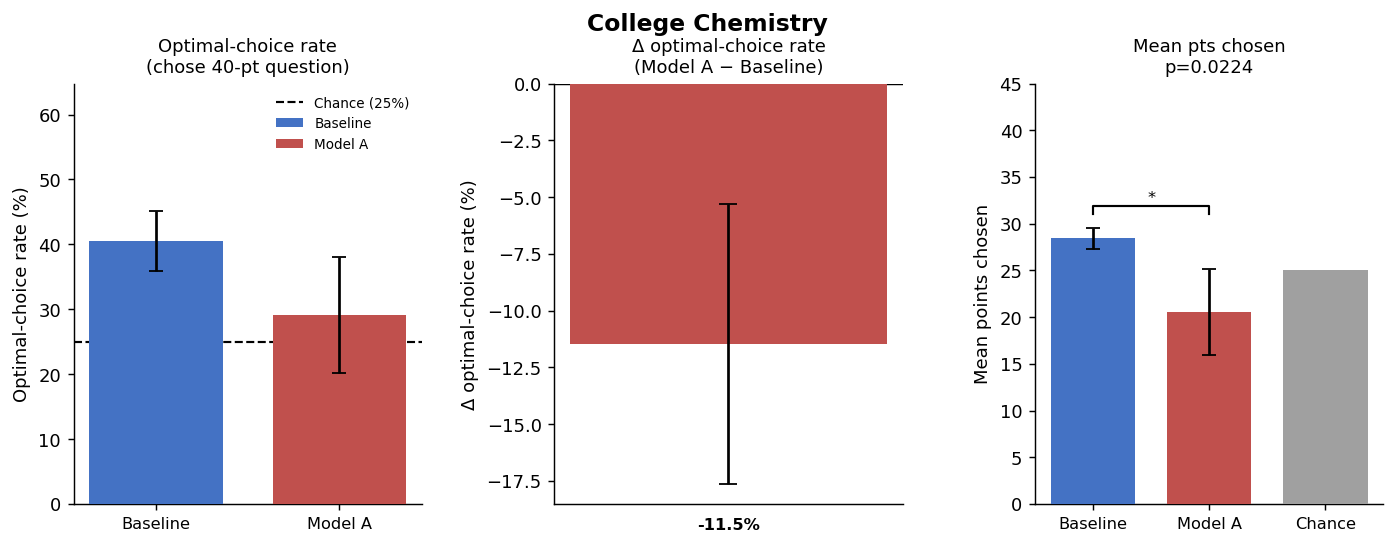

  Saved → results/figures/college_chemistry.png



In [ ]:
# ════════════════════════════════════════════════════════════════════════
# FIGURE 1 — One 3-panel figure per subject  (matches reference figure)
# ════════════════════════════════════════════════════════════════════════
#
# Panel 1: Optimal-choice rate (%)  → Baseline vs Model A, chance at 25%
# Panel 2: Δ optimal-choice rate    → Model A − Baseline per fold (whiskers)
# Panel 3: Mean pts chosen          → Baseline / Model A / Chance=25

os.makedirs('results/figures', exist_ok=True)

for subj in subjects:
    p = parsed[subj]

    # Paired t-test on avg_pts (5 folds)
    t_stat, t_p = stats.ttest_rel(p['base_pts'], p['moda_pts'])

    fig = plt.figure(figsize=(13, 4.2))
    fig.suptitle(subj.replace('_', ' ').title(), fontsize=13, fontweight='bold', y=1.01)
    gs  = gridspec.GridSpec(1, 3, wspace=0.38)

    # ── Panel 1: Optimal-choice rate ─────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    x   = np.array([0, 0.55])
    bars_b = ax1.bar(x[0], p['base_opt'].mean(), width=0.4, color=BLUE,
                     label='Baseline', zorder=3)
    bars_m = ax1.bar(x[1], p['moda_opt'].mean(), width=0.4, color=RED,
                     label='Model A',  zorder=3)
    ax1.errorbar(x[0], p['base_opt'].mean(), yerr=p['base_opt'].std(),
                 fmt='none', c='k', capsize=4, lw=1.5, zorder=4)
    ax1.errorbar(x[1], p['moda_opt'].mean(), yerr=p['moda_opt'].std(),
                 fmt='none', c='k', capsize=4, lw=1.5, zorder=4)
    ax1.axhline(CHANCE, ls='--', c='k', lw=1.2, label='Chance (25%)')
    ax1.set_xticks(x); ax1.set_xticklabels(['Baseline', 'Model A'], fontsize=9)
    ax1.set_ylim(0, min(105, max(p['base_opt'].mean(), p['moda_opt'].mean()) * 1.35 + 10))
    ax1.set_ylabel('Optimal-choice rate (%)')
    ax1.set_title('Optimal-choice rate\n(chose 40-pt question)', fontsize=10)
    ax1.legend(fontsize=7.5, frameon=False)

    # ── Panel 2: Δ optimal-choice rate per fold ───────────────────────────
    ax2 = fig.add_subplot(gs[1])
    delta_mean = p['delta_opt'].mean()
    delta_std  = p['delta_opt'].std()
    color      = GREEN if delta_mean >= 0 else RED
    ax2.bar(0, delta_mean, width=0.5, color=color, zorder=3)
    ax2.errorbar(0, delta_mean, yerr=delta_std,
                 fmt='none', c='k', capsize=5, lw=1.5, zorder=4)
    ax2.axhline(0, c='k', lw=0.8)
    ax2.set_xticks([])
    ax2.set_ylabel('Δ optimal-choice rate (%)')
    ax2.set_title('Δ optimal-choice rate\n(Model A − Baseline)', fontsize=10)
    # Annotate value
    ax2.text(0, delta_mean + np.sign(delta_mean) * (delta_std + 1.5),
             f'{delta_mean:+.1f}%', ha='center', va='bottom' if delta_mean >= 0 else 'top',
             fontsize=9, fontweight='bold')

    # ── Panel 3: Mean pts chosen ──────────────────────────────────────────
    ax3   = fig.add_subplot(gs[2])
    x3    = np.array([0, 0.55, 1.1])
    vals  = [p['base_pts'].mean(), p['moda_pts'].mean(), CHANCE]
    errs  = [p['base_pts'].std(),  p['moda_pts'].std(),  0]
    cols  = [BLUE, RED, GREY]
    for xi, vi, ei, ci in zip(x3, vals, errs, cols):
        ax3.bar(xi, vi, width=0.4, color=ci, zorder=3)
        if ei > 0:
            ax3.errorbar(xi, vi, yerr=ei, fmt='none', c='k',
                         capsize=4, lw=1.5, zorder=4)
    ax3.set_xticks(x3)
    ax3.set_xticklabels(['Baseline', 'Model A', 'Chance'], fontsize=9)
    ax3.set_ylim(0, 45)
    ax3.set_ylabel('Mean points chosen')
    ax3.set_title(f'Mean pts chosen\np={t_p:.4f}', fontsize=10)
    # Significance bracket
    ymax = max(vals[0] + errs[0], vals[1] + errs[1]) + 1.5
    bracket(ax3, x3[0], x3[1], ymax, sig_stars(t_p))

    plt.tight_layout()
    fname = f'results/figures/{subj}.png'
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'  Saved → {fname}\n')

In [ ]:
# ════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Global summary (all 10 subjects pooled)
# ════════════════════════════════════════════════════════════════════════

all_base_pts = np.concatenate([parsed[s]['base_pts'] for s in subjects])
all_moda_pts = np.concatenate([parsed[s]['moda_pts'] for s in subjects])
all_base_opt = np.concatenate([parsed[s]['base_opt'] for s in subjects])
all_moda_opt = np.concatenate([parsed[s]['moda_opt'] for s in subjects])

t_pts_stat, t_pts_p = stats.ttest_rel(all_base_pts, all_moda_pts)
t_opt_stat, t_opt_p = stats.ttest_rel(all_base_opt, all_moda_opt)

fig = plt.figure(figsize=(13, 4.5))
fig.suptitle('Global Summary — All 10 Subjects', fontsize=14, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(1, 3, wspace=0.38)

# Panel 1: Optimal-choice rate — global
ax1 = fig.add_subplot(gs[0])
x   = np.array([0, 0.55])
ax1.bar(x[0], all_base_opt.mean(), width=0.4, color=BLUE, label='Baseline')
ax1.bar(x[1], all_moda_opt.mean(), width=0.4, color=RED,  label='Model A')
ax1.errorbar(x[0], all_base_opt.mean(), yerr=all_base_opt.std(),
             fmt='none', c='k', capsize=5, lw=1.5)
ax1.errorbar(x[1], all_moda_opt.mean(), yerr=all_moda_opt.std(),
             fmt='none', c='k', capsize=5, lw=1.5)
ax1.axhline(CHANCE, ls='--', c='k', lw=1.2, label='Chance (25%)')
ymax1 = max(all_base_opt.mean(), all_moda_opt.mean()) + all_base_opt.std() + 8
bracket(ax1, x[0], x[1], ymax1, sig_stars(t_opt_p))
ax1.set_xticks(x); ax1.set_xticklabels(['Baseline', 'Model A'])
ax1.set_ylim(0, ymax1 + 6)
ax1.set_ylabel('Optimal-choice rate (%)')
ax1.set_title(f'Optimal-choice rate\np={t_opt_p:.4f}', fontsize=10)
ax1.legend(fontsize=8, frameon=False)

# Panel 2: Per-subject Δ optimal rate (one bar per subject)
ax2 = fig.add_subplot(gs[1])
deltas = [parsed[s]['delta_opt'].mean() for s in subjects]
colors = [GREEN if d >= 0 else RED for d in deltas]
xpos   = np.arange(len(subjects))
ax2.bar(xpos, deltas, color=colors, width=0.7, zorder=3)
ax2.errorbar(xpos, deltas,
             yerr=[parsed[s]['delta_opt'].std() for s in subjects],
             fmt='none', c='k', capsize=3, lw=1.2, zorder=4)
ax2.axhline(0, c='k', lw=0.8)
ax2.set_xticks(xpos)
ax2.set_xticklabels([s.replace('_', '\n') for s in subjects],
                    fontsize=6, rotation=0)
ax2.set_ylabel('Δ optimal-choice rate (%)')
ax2.set_title('Δ optimal-choice rate per subject\n(Model A − Baseline)', fontsize=10)

# Panel 3: Mean pts — global
ax3  = fig.add_subplot(gs[2])
x3   = np.array([0, 0.55, 1.1])
vals = [all_base_pts.mean(), all_moda_pts.mean(), CHANCE]
errs = [all_base_pts.std(),  all_moda_pts.std(),  0]
cols = [BLUE, RED, GREY]
for xi, vi, ei, ci in zip(x3, vals, errs, cols):
    ax3.bar(xi, vi, width=0.4, color=ci, zorder=3)
    if ei > 0:
        ax3.errorbar(xi, vi, yerr=ei, fmt='none', c='k', capsize=5, lw=1.5, zorder=4)
ax3.set_xticks(x3)
ax3.set_xticklabels(['Baseline', 'Model A', 'Chance'])
ax3.set_ylim(0, 45)
ax3.set_ylabel('Mean points chosen')
ax3.set_title(f'Mean pts chosen\np={t_pts_p:.4f}', fontsize=10)
ymax3 = max(vals[0] + errs[0], vals[1] + errs[1]) + 1.5
bracket(ax3, x3[0], x3[1], ymax3, sig_stars(t_pts_p))

plt.tight_layout()
plt.savefig('results/figures/global_summary.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved → results/figures/global_summary.png')

In [ ]:
# ════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Summary table
# ════════════════════════════════════════════════════════════════════════

rows = []
for s in subjects:
    p = parsed[s]
    t_stat, t_p = stats.ttest_rel(p['base_pts'], p['moda_pts'])
    rows.append({
        'Subject':        s.replace('_', ' '),
        'Base pts':       f"{p['base_pts'].mean():.2f} ± {p['base_pts'].std():.2f}",
        'ModA pts':       f"{p['moda_pts'].mean():.2f} ± {p['moda_pts'].std():.2f}",
        'Δ pts':          f"{p['delta_pts'].mean():+.2f}",
        'Base opt %':     f"{p['base_opt'].mean():.1f} ± {p['base_opt'].std():.1f}",
        'ModA opt %':     f"{p['moda_opt'].mean():.1f} ± {p['moda_opt'].std():.1f}",
        'Δ opt %':        f"{p['delta_opt'].mean():+.1f}",
        'p (pts)':        f"{t_p:.4f}",
        'sig':            sig_stars(t_p),
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv('results/mmlu_difficulty_summary_table.csv', index=False)
print('\nSaved → results/mmlu_difficulty_summary_table.csv')